# Research Notebook - Computational Finance

This notebook compares three technical trading signals:

- MACD
- RSI
- Donchian Channel Breakout

Signals are calibrated on the 2010-2019 in-sample period and evaluated on the 2020-2025 out-of-sample period. Strategy returns use a one-day lag between signal generation and return realization.


In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import module
importlib.reload(module)

<module 'module' from 'C:\\Users\\User\\PycharmProjects\\JupyterProject\\Computational-Finance\\Computational-Finance\\module.py'>

In [2]:
# Verify all required module functions loaded correctly.
print(hasattr(module, 'macd_signal'))
print(hasattr(module, 'rsi_signal'))
print(hasattr(module, 'donchian_signal'))
print(hasattr(module, 'exponential_moving_average'))
print(hasattr(module, 'grid_search_parameters'))
print(hasattr(module, 'split_in_sample_out_of_sample'))


True
True
True
True
True
True


## 1. Extended Data Loading - Sector Baskets

| Basket | Stocks | Signal tested |
|---|---|---|
| Financials | BRK-B, JPM | MACD |
| Technology | NVDA, GOOGL | RSI |
| Healthcare | LLY, JNJ | Donchian |


In [3]:
# ── BASKET DEFINITIONS ───────────────────────────────────────────────────────
import os, pathlib

FINANCE_TICKERS    = ['BRK-B', 'JPM']
TECH_TICKERS       = ['NVDA', 'GOOGL']
HEALTHCARE_TICKERS = ['LLY', 'JNJ']

IS_END    = '2019-12-31'
OOS_START = '2020-01-01'

data_dir = pathlib.Path('data')
data_dir.mkdir(exist_ok=True)

try:
    import yfinance as yf
    _yf_ok = True
except ImportError:
    _yf_ok = False

def _load_basket(tickers_list, csv_name, start='2010-01-01', end='2025-12-31'):
    csv_path = data_dir / csv_name
    if csv_path.exists():
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
        df = df[[t for t in tickers_list if t in df.columns]]
        print(f'Loaded {csv_name} from cache.')
    else:
        try:
            df, _ = module.download_stock_price_data(tickers_list, start, end)
            df.to_csv(csv_path)
            print(f'Downloaded {csv_name} via yahooquery.')
        except Exception as exc_yq:
            print(f'yahooquery failed ({exc_yq}). Trying yfinance...')
            if not _yf_ok:
                raise RuntimeError('Install yfinance: pip install yfinance')
            raw = yf.download(tickers_list, start=start, end=end,
                              progress=False, auto_adjust=True)
            df = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw
            bidx = pd.date_range(start=start, end=end, freq='B')
            df = df.reindex(bidx).ffill().dropna()
            df.to_csv(csv_path)
            print(f'Downloaded {csv_name} via yfinance.')
    df.index = pd.to_datetime(df.index)
    return df

df_finance    = _load_basket(FINANCE_TICKERS,    'finance.csv')
df_tech       = _load_basket(TECH_TICKERS,       'tech.csv')
df_healthcare = _load_basket(HEALTHCARE_TICKERS, 'healthcare.csv')

# ← CHANGE 1: use pd.Timestamp for safe DatetimeIndex comparison
def _split(df):
    is_  = df[df.index <= pd.Timestamp(IS_END)]
    oos_ = df[df.index >= pd.Timestamp(OOS_START)]
    return is_, oos_

df_finance_is,    df_finance_oos    = _split(df_finance)
df_tech_is,       df_tech_oos       = _split(df_tech)
df_healthcare_is, df_healthcare_oos = _split(df_healthcare)

spx_csv = data_dir / 'spx.csv'
if spx_csv.exists():
    df_spx = pd.read_csv(spx_csv, index_col=0, parse_dates=True)
    print('Loaded spx.csv from cache.')
else:
    df_spx, _ = module.download_stock_price_data(['^GSPC'], '2010-01-01', '2025-12-31')
    df_spx.to_csv(spx_csv)
df_spx.index = pd.to_datetime(df_spx.index)

print(f'\nBasket shapes  Finance: {df_finance.shape}  Tech: {df_tech.shape}  Healthcare: {df_healthcare.shape}')
print(f'IS window  : {df_finance_is.index[0].date()} - {df_finance_is.index[-1].date()} ({len(df_finance_is)} days)')
print(f'OOS window : {df_finance_oos.index[0].date()} - {df_finance_oos.index[-1].date()} ({len(df_finance_oos)} days)')

Loaded finance.csv from cache.
Loaded tech.csv from cache.
Loaded healthcare.csv from cache.
Loaded spx.csv from cache.

Basket shapes  Finance: (4023, 2)  Tech: (4023, 2)  Healthcare: (4023, 2)
IS window  : 2010-01-04 - 2019-12-31 (2516 days)
OOS window : 2020-01-02 - 2025-12-30 (1507 days)


## 2. Signal-to-Industry Assignment

| Signal | Sector | Stocks | Rationale |
|---|---|---|---|
| MACD | Financials | BRK-B, JPM | Interest-rate and credit-cycle news can create persistent momentum. |
| RSI | Technology | NVDA, GOOGL | High-beta technology names often overshoot around earnings and sentiment shocks. |
| Donchian | Healthcare | LLY, JNJ | Breakouts test whether defensive-sector leadership persists after prices leave a recent range. |

### Donchian -> Healthcare (LLY, JNJ)

The Donchian Channel is a breakout signal: it enters when price moves above a previous rolling high and exits when price falls below a previous rolling low. In this notebook it replaces the old third-signal experiment so we can test a trend-breakout mechanism alongside MACD and RSI.


In [4]:
# Signal-to-industry assignment
# Donchian replaces the old third signal to test breakout behaviour.
signal_assignments = {
    'MACD': {
        'signal_fn' : module.macd_signal,
        'stocks'    : ['BRK-B', 'JPM'],
        'sector'    : 'Financials',
        'rationale' : 'Interest rate cycles create sustained momentum; MACD captures acceleration'
    },
    'RSI': {
        'signal_fn' : module.rsi_signal,
        'stocks'    : ['NVDA', 'GOOGL'],
        'sector'    : 'Technology',
        'rationale' : 'High-beta tech overshoots on earnings; RSI captures overbought/oversold extremes'
    },
    'Donchian': {
        'signal_fn' : module.donchian_signal,
        'stocks'    : ['LLY', 'JNJ'],
        'sector'    : 'Healthcare',
        'rationale' : 'Breakouts above recent ranges test whether defensive-sector trends persist'
    }
}

print('Signal-to-Industry Assignment')
print('=' * 60)
for signal_name, info in signal_assignments.items():
    print(f"\n{signal_name} -> {info['sector']} ({', '.join(info['stocks'])})")
    print(f"  Logic: {info['rationale']}")


Signal-to-Industry Assignment

MACD -> Financials (BRK-B, JPM)
  Logic: Interest rate cycles create sustained momentum; MACD captures acceleration

RSI -> Technology (NVDA, GOOGL)
  Logic: High-beta tech overshoots on earnings; RSI captures overbought/oversold extremes

Donchian -> Healthcare (LLY, JNJ)
  Logic: Breakouts above recent ranges test whether defensive-sector trends persist


## 3. Signal Exploration (In-Sample: 2010-2019)

This section tests candidate signals on all stocks with default parameters. The goal is exploratory only: parameter selection happens later and uses only in-sample data.


In [5]:
# Test all signals on all stocks using default parameters (in-sample only).
# Strategy returns use yesterday's signal to earn today's return.

test_stocks = ['BRK-B', 'JPM', 'LLY', 'JNJ', 'NVDA', 'GOOGL']

signals = {
    'MA Crossover' : lambda s: module.ma_signal(s, 50, 200),
    'RSI'          : lambda s: module.rsi_signal(s),
    'Bollinger'    : lambda s: module.bollinger_signal(s),
    'MACD'         : lambda s: module.macd_signal(s),
    'Donchian'     : lambda s: module.donchian_signal(s, window=55),
}

prices_is = pd.concat([df_finance_is, df_tech_is, df_healthcare_is], axis=1)
prices_is.index = pd.to_datetime(prices_is.index)

results = {}
for signal_name, signal_fn in signals.items():
    results[signal_name] = {}
    for stock in test_stocks:
        try:
            sig_df = signal_fn(prices_is[stock])
            signal_arr = sig_df['signal'].to_numpy(dtype=float)
            prices_arr = prices_is[stock].to_numpy(dtype=float)
            daily_ret = np.concatenate(([0.0], prices_arr[1:] / prices_arr[:-1] - 1))
            position = np.concatenate(([0.0], signal_arr[:-1]))
            strat_ret = (position * daily_ret)[1:]
            results[signal_name][stock] = round(module.compute_sharpe(strat_ret), 3)
        except Exception:
            results[signal_name][stock] = np.nan

df_results = pd.DataFrame(results).T
print('Sharpe Ratios - In-Sample (2010-2019) - Default Parameters')
print('=' * 60)
print(df_results.to_string())
print()
print('Best signal per stock:')
for stock in test_stocks:
    best_signal = df_results[stock].idxmax()
    best_sharpe = df_results[stock].max()
    print(f'  {stock}: {best_signal} (Sharpe: {best_sharpe})')


Sharpe Ratios - In-Sample (2010-2019) - Default Parameters
              BRK-B    JPM    LLY    JNJ   NVDA  GOOGL
MA Crossover  0.726  0.613  0.562  0.593  1.030  0.513
RSI           0.559  0.755  1.004  0.566  0.217  0.748
Bollinger     0.716  0.488  0.552  0.588  0.366  0.627
MACD          0.202  0.630  0.448  0.401  0.363  0.593
Donchian      0.615  0.324  0.654  0.363  0.954  0.513

Best signal per stock:
  BRK-B: MA Crossover (Sharpe: 0.726)
  JPM: RSI (Sharpe: 0.755)
  LLY: RSI (Sharpe: 1.004)
  JNJ: MA Crossover (Sharpe: 0.593)
  NVDA: MA Crossover (Sharpe: 1.03)
  GOOGL: RSI (Sharpe: 0.748)


In [6]:
# Check how often MACD and Donchian are active on representative stocks.
sig_macd = module.macd_signal(prices_is['JPM'])
sig_donchian = module.donchian_signal(prices_is['JNJ'], window=55)

print(f'MACD active days:      {sig_macd["signal"].sum():.0f} out of {len(sig_macd)}')
print(f'Donchian active days:  {sig_donchian["signal"].sum():.0f} out of {len(sig_donchian)}')
print()
print(f'MACD trades:      {(sig_macd["position_change"] > 0).sum()}')
print(f'Donchian trades:  {(sig_donchian["position_change"] > 0).sum()}')


MACD active days:      1285 out of 2516
Donchian active days:  1554 out of 2516

MACD trades:      95
Donchian trades:  18


### 3.1 Findings

The default-parameter scan is only a rough diagnostic. Donchian is included to test a breakout-style mechanism that is distinct from RSI mean reversion and MACD moving-average momentum. Because all reported strategy returns use lagged positions, these exploratory Sharpe ratios avoid same-day look-ahead bias.


## 4. Parameter Optimization (In-Sample: 2010-2019)

For each signal we perform an exhaustive grid search over candidate parameter
combinations using only the in-sample period (2010-2019). The best parameters
are selected based on the Sortino ratio — which penalises only downside
volatility, better reflecting investor preferences than the Sharpe ratio.

Parameters are optimized separately for each stock in the sector basket.
The final parameters chosen for the assessment notebook are those that
perform consistently well across both stocks in the sector.

**Important:** The out-of-sample period (2020-2025) is never touched during
this step. Parameters are frozen after this section.

In [7]:
# PARAMETER OPTIMIZATION
# Grid search for each signal on its assigned stocks (in-sample only).

macd_param_grid = {
    'fast_span'   : [8, 10, 12, 15],
    'slow_span'   : [20, 24, 26, 30],
    'signal_span' : [7, 9, 11]
}

rsi_param_grid = {
    'period'     : [7, 10, 14, 20, 30],
    'oversold'   : [20, 25, 30, 35],
    'overbought' : [65, 70, 75, 80]
}

donchian_param_grid = {
    'window': [20, 40, 55, 75, 100, 150, 200]
}

print('Running parameter optimization (in-sample 2010-2019)...')
print('This may take a minute - testing all parameter combinations')
print('=' * 60)

optimization_results = {}

for signal_name, info in signal_assignments.items():
    optimization_results[signal_name] = {}

    if signal_name == 'MACD':
        param_grid = macd_param_grid
    elif signal_name == 'RSI':
        param_grid = rsi_param_grid
    else:
        param_grid = donchian_param_grid

    print(f'\n{signal_name} ({info["sector"]}):')

    for stock in info['stocks']:
        if stock in ['BRK-B', 'JPM']:
            price_series = df_finance_is[stock]
        elif stock in ['NVDA', 'GOOGL']:
            price_series = df_tech_is[stock]
        else:
            price_series = df_healthcare_is[stock]

        best_params, best_score, _ = module.grid_search_parameters(
            info['signal_fn'],
            price_series,
            param_grid
        )

        optimization_results[signal_name][stock] = {
            'best_params': best_params,
            'best_score' : round(best_score, 3)
        }
        print(f'  {stock}: best params = {best_params}')
        print(f'          Sortino     = {best_score:.3f}')


Running parameter optimization (in-sample 2010-2019)...
This may take a minute - testing all parameter combinations

MACD (Financials):


  BRK-B: best params = {'signal_span': 11, 'slow_span': 30, 'fast_span': 15}
          Sortino     = 0.635


  JPM: best params = {'signal_span': 7, 'slow_span': 26, 'fast_span': 10}
          Sortino     = 1.166

RSI (Technology):


  NVDA: best params = {'overbought': 75, 'oversold': 35, 'period': 7}
          Sortino     = 0.916


  GOOGL: best params = {'overbought': 75, 'oversold': 35, 'period': 14}
          Sortino     = 1.519

Donchian (Healthcare):
  LLY: best params = {'window': 55}
          Sortino     = 0.948
  JNJ: best params = {'window': 40}
          Sortino     = 0.533


### Finding:

Parameter optimization now includes Donchian on the Healthcare basket. The important comparison is not whether Donchian wins under defaults, but whether its in-sample-selected window produces persistent out-of-sample performance.


In [8]:
# Quick test: MACD on Technology and Healthcare
print('Testing MACD on Technology and Healthcare:')
for stock in ['NVDA', 'GOOGL', 'LLY', 'JNJ']:
    if stock in ['NVDA', 'GOOGL']:
        price_series = df_tech_is[stock]
    else:
        price_series = df_healthcare_is[stock]

    best_params, best_score, _ = module.grid_search_parameters(
        module.macd_signal,
        price_series,
        macd_param_grid
    )
    print(f'  {stock}: Sortino = {best_score:.3f}, params = {best_params}')

Testing MACD on Technology and Healthcare:


  NVDA: Sortino = 0.771, params = {'signal_span': 7, 'slow_span': 20, 'fast_span': 10}


  GOOGL: Sortino = 1.143, params = {'signal_span': 11, 'slow_span': 30, 'fast_span': 10}


  LLY: Sortino = 0.955, params = {'signal_span': 7, 'slow_span': 26, 'fast_span': 8}


  JNJ: Sortino = 0.681, params = {'signal_span': 9, 'slow_span': 26, 'fast_span': 15}


## 4. Parameter Optimisation (In-Sample: 2010-2019)

| Signal | Basket | Parameter grid |
|---|---|---|
| MACD | Finance (BRK-B, JPM) | fast_span, slow_span, signal_span |
| RSI | Technology (NVDA, GOOGL) | oversold, overbought, period fixed at 14 |
| Donchian | Healthcare (LLY, JNJ) | window in [20, 40, 55, 75, 100, 150, 200] |


In [9]:
# BASKET-LEVEL SORTINO HELPER
# For basket signals we average the Sortino across all stocks in the basket.
# Yesterday's signal earns today's return to avoid look-ahead bias.

def basket_sortino(signal_fn, df_basket, **params):
    scores = []
    for col in df_basket.columns:
        px = df_basket[col].to_numpy(dtype=float)
        dr = np.concatenate(([0.0], px[1:] / px[:-1] - 1))
        try:
            sig = signal_fn(df_basket[col], **params)
            arr = sig['signal'].to_numpy(dtype=float)
            position = np.concatenate(([0.0], arr[:-1]))
            strat = (position * dr)[1:]
            s = module.compute_sortino(strat)
            if not np.isnan(s):
                scores.append(s)
        except Exception:
            pass
    return np.mean(scores) if scores else np.nan


In [10]:
# PARAMETER GRID SEARCH (IS ONLY)
# For each signal, sweep parameters on basket-averaged IS Sortino.
# OOS data is never touched at this stage.

fast_spans   = [8, 10, 12, 15]
slow_spans   = [20, 24, 26, 30]
signal_spans = [7, 9, 11]

macd_grid_results = []
for ss in signal_spans:
    for slow in slow_spans:
        for fast in fast_spans:
            if fast >= slow:
                macd_grid_results.append(
                    ({'fast_span': fast, 'slow_span': slow, 'signal_span': ss}, np.nan))
                continue
            score = basket_sortino(module.macd_signal, df_finance_is,
                                   fast_span=fast, slow_span=slow, signal_span=ss)
            macd_grid_results.append(
                ({'fast_span': fast, 'slow_span': slow, 'signal_span': ss}, score))

best_macd = max(macd_grid_results,
                key=lambda x: x[1] if not np.isnan(x[1]) else -np.inf)
_best_macd_params, _best_macd_score = best_macd
print(f'Signal 0 (MACD, Finance)        -> IS-optimal: {_best_macd_params}  '
      f'Sortino = {_best_macd_score:.3f}')

oversold_levels   = [15, 20, 25, 30, 35, 40]
overbought_levels = [60, 65, 70, 75, 80, 85]

rsi_grid_results = []
for ob in overbought_levels:
    for os_ in oversold_levels:
        if os_ >= ob:
            rsi_grid_results.append(
                ({'period': 14, 'oversold': os_, 'overbought': ob}, np.nan))
            continue
        score = basket_sortino(module.rsi_signal, df_tech_is,
                               period=14, oversold=os_, overbought=ob)
        rsi_grid_results.append(
            ({'period': 14, 'oversold': os_, 'overbought': ob}, score))

best_rsi = max(rsi_grid_results,
               key=lambda x: x[1] if not np.isnan(x[1]) else -np.inf)
_best_rsi_params, _best_rsi_score = best_rsi
print(f'Signal 1 (RSI, Technology)      -> IS-optimal: {_best_rsi_params}  '
      f'Sortino = {_best_rsi_score:.3f}')

donchian_windows = [20, 40, 55, 75, 100, 150, 200]

donchian_grid_results = []
for window in donchian_windows:
    score = basket_sortino(module.donchian_signal, df_healthcare_is, window=window)
    donchian_grid_results.append(({'window': window}, score))

best_donchian = max(donchian_grid_results,
                    key=lambda x: x[1] if not np.isnan(x[1]) else -np.inf)
_best_donchian_params, _best_donchian_score = best_donchian
print(f'Signal 2 (Donchian, Healthcare) -> IS-optimal: {_best_donchian_params}  '
      f'Sortino = {_best_donchian_score:.3f}')


Signal 0 (MACD, Finance)        -> IS-optimal: {'fast_span': 15, 'slow_span': 26, 'signal_span': 11}  Sortino = 0.806


Signal 1 (RSI, Technology)      -> IS-optimal: {'period': 14, 'oversold': 35, 'overbought': 85}  Sortino = 1.190
Signal 2 (Donchian, Healthcare) -> IS-optimal: {'window': 200}  Sortino = 1.043


In [11]:
# PARAMETER RESULTS TABLE
# Full grid results sorted by IS Sortino

def print_grid_results(grid_results, title, columns):
    sorted_results = sorted(grid_results,
                            key=lambda x: x[1] if not np.isnan(x[1]) else -np.inf,
                            reverse=True)
    best = sorted_results[0][0]
    print(f'\n{"="*65}')
    print(f'  {title}')
    print(f'{"="*65}')
    header = ''.join([f'{c:<18}' for c in columns])
    print(f'  {header} {"IS Sortino":>12}')
    print(f'  {"-"*58}')
    for params, score in sorted_results:
        tag = ' <-- best' if params == best else ''
        score_str = f'{score:>12.4f}' if not np.isnan(score) else '         NaN'
        param_str = ''.join([f'{str(params[c]):<18}' for c in columns])
        print(f'  {param_str} {score_str}{tag}')
    print(f'{"="*65}')
    print(f'  Best params: {best}')

print_grid_results(macd_grid_results,
                   'Signal 0 - MACD  |  Finance (BRK-B, JPM)',
                   ['fast_span', 'slow_span', 'signal_span'])

print_grid_results(rsi_grid_results,
                   'Signal 1 - RSI  |  Technology (NVDA, GOOGL)',
                   ['oversold', 'overbought'])

print_grid_results(donchian_grid_results,
                   'Signal 2 - Donchian  |  Healthcare (LLY, JNJ)',
                   ['window'])



  Signal 0 - MACD  |  Finance (BRK-B, JPM)
  fast_span         slow_span         signal_span          IS Sortino
  ----------------------------------------------------------
  15                26                11                       0.8057 <-- best
  15                30                11                       0.7821
  8                 30                7                        0.7787
  10                20                7                        0.7759
  8                 20                9                        0.7704
  8                 26                9                        0.7599
  8                 24                7                        0.7522
  8                 24                9                        0.7496
  8                 26                7                        0.7467
  10                24                7                        0.7393
  8                 20                7                        0.7364
  15                30                9       

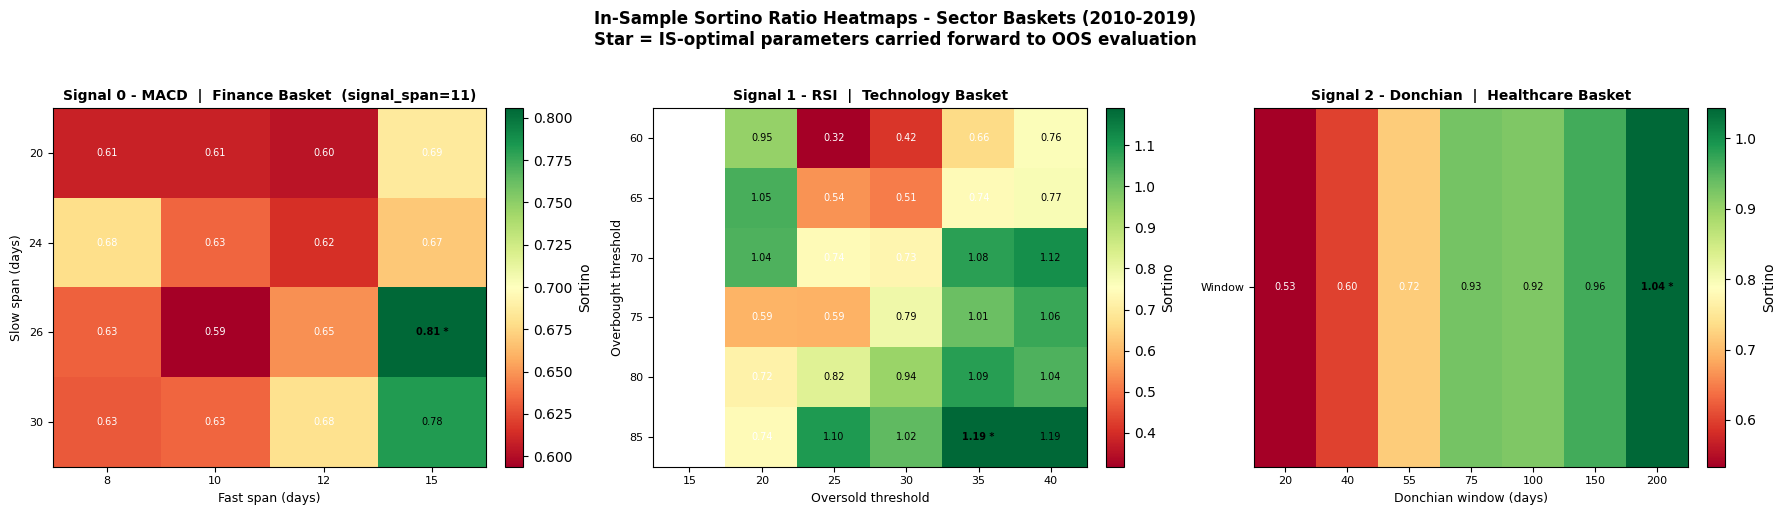

In [12]:
# SENSITIVITY HEATMAPS
# Maps the full IS Sortino landscape for each signal.

def build_matrix(grid_results, row_vals, col_vals, row_key, col_key):
    mat = np.full((len(row_vals), len(col_vals)), np.nan)
    for params, score in grid_results:
        r = row_vals.index(params[row_key]) if params[row_key] in row_vals else -1
        c = col_vals.index(params[col_key]) if params[col_key] in col_vals else -1
        if r >= 0 and c >= 0:
            mat[r, c] = score if not np.isnan(score) else np.nan
    return mat

macd_matrix = build_matrix(
    [(p, s) for p, s in macd_grid_results
     if p.get('signal_span') == _best_macd_params['signal_span']],
    slow_spans, fast_spans, 'slow_span', 'fast_span')

rsi_matrix = build_matrix(rsi_grid_results,
                           overbought_levels, oversold_levels,
                           'overbought', 'oversold')

donchian_scores = np.array([
    score if not np.isnan(score) else np.nan
    for _, score in donchian_grid_results
], dtype=float).reshape(1, -1)

def draw_heatmap(ax, data, row_labels, col_labels, row_title, col_title,
                 title, star_row, star_col):
    vmin = float(np.nanmin(data)) if not np.all(np.isnan(data)) else -1
    vmax = float(np.nanmax(data)) if not np.all(np.isnan(data)) else  1
    im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, fontsize=8)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=8)
    ax.set_xlabel(col_title, fontsize=9)
    ax.set_ylabel(row_title, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    mid = (vmin + vmax) / 2
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            if not np.isnan(data[r, c]):
                marker = ' *' if (r == star_row and c == star_col) else ''
                tc = 'black' if data[r, c] > mid else 'white'
                ax.text(c, r, f'{data[r,c]:.2f}{marker}',
                        ha='center', va='center', fontsize=7, color=tc,
                        fontweight='bold' if marker else 'normal')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Sortino')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'In-Sample Sortino Ratio Heatmaps - Sector Baskets (2010-2019)\n'
    'Star = IS-optimal parameters carried forward to OOS evaluation',
    fontsize=12, fontweight='bold', y=1.02)

draw_heatmap(axes[0], macd_matrix,
             [str(s) for s in slow_spans],
             [str(f) for f in fast_spans],
             'Slow span (days)', 'Fast span (days)',
             f'Signal 0 - MACD  |  Finance Basket  (signal_span={_best_macd_params["signal_span"]})',
             star_row=slow_spans.index(_best_macd_params['slow_span']),
             star_col=fast_spans.index(_best_macd_params['fast_span']))

draw_heatmap(axes[1], rsi_matrix,
             [str(o) for o in overbought_levels],
             [str(o) for o in oversold_levels],
             'Overbought threshold', 'Oversold threshold',
             'Signal 1 - RSI  |  Technology Basket',
             star_row=overbought_levels.index(_best_rsi_params['overbought']),
             star_col=oversold_levels.index(_best_rsi_params['oversold']))

draw_heatmap(axes[2], donchian_scores,
             ['Window'],
             [str(w) for w in donchian_windows],
             '', 'Donchian window (days)',
             'Signal 2 - Donchian  |  Healthcare Basket',
             star_row=0,
             star_col=donchian_windows.index(_best_donchian_params['window']))

plt.tight_layout()
plt.show()


### 4.3 Findings

The heatmaps show the in-sample Sortino landscape for each tested signal. Donchian is displayed as a one-dimensional window sweep, with the selected window carried forward unchanged into out-of-sample validation.


## 5. Walk-Forward Out-of-Sample Validation (2020-2025)

### 5.1 Methodology

The IS-optimal parameters found in Section 4 are now frozen.
The OOS window (2020-2025) is evaluated for the first time here.
No re-fitting or parameter adjustment is performed — any change
would introduce data-snooping bias (Pardo, 2008).

The OOS window deliberately spans five structurally distinct sub-regimes:

| Sub-regime | Dates | Dominant driver |
|---|---|---|
| COVID crash | Feb-Apr 2020 | Exogenous demand shock; VIX > 80 |
| Monetary stimulus rally | May 2020 - Dec 2021 | Near-zero rates, fiscal expansion |
| Fed tightening cycle | Jan 2022 - Dec 2022 | Fastest rate-hike cycle since 1980s |
| AI-driven recovery | Jan 2023 - Dec 2024 | Productivity narrative, mega-cap outperformance |
| Tariff / geopolitical shock | Jan 2025 - present | Trade policy uncertainty, supply-chain repricing |

A signal that delivers positive Sortino ratios across all five sub-regimes
provides strong evidence of a structural market mechanism rather than a
regime-specific artefact.

**References:**
- Pardo, R. (2008). The Evaluation and Optimization of Trading Strategies. Wiley.
- White, H. (2000). A Reality Check for Data Snooping. Econometrica, 68(5).

In [13]:
# PORTFOLIO VALUE HELPER
# Equal-weight basket portfolio with one-day signal lag and 10 bps one-way costs.

TRADE_COST = 0.001

def basket_portfolio_value(signal_fn, df_basket, params):
    n_stocks = len(df_basket.columns)
    weight = 1.0 / n_stocks

    returns_matrix = np.zeros((len(df_basket), n_stocks))
    signals_matrix = np.zeros((len(df_basket), n_stocks))

    for j, col in enumerate(df_basket.columns):
        px = df_basket[col].to_numpy(dtype=float)
        returns_matrix[:, j] = np.concatenate(([0.0], px[1:] / px[:-1] - 1))
        try:
            sig = signal_fn(df_basket[col], **params)
            signals_matrix[:, j] = sig['signal'].to_numpy(dtype=float)
        except Exception:
            pass

    position_matrix = np.vstack([
        np.zeros((1, n_stocks)),
        signals_matrix[:-1]
    ])
    previous_position = np.vstack([
        np.zeros((1, n_stocks)),
        position_matrix[:-1]
    ])
    trade_matrix = np.abs(position_matrix - previous_position)

    daily_gross = np.sum(position_matrix * returns_matrix, axis=1) * weight
    daily_cost = np.sum(trade_matrix, axis=1) * TRADE_COST * weight
    daily_net = daily_gross - daily_cost

    gross_pv = np.cumprod(1.0 + daily_gross)
    net_pv = np.cumprod(1.0 + daily_net)

    return gross_pv, net_pv

def _spx_slice(df_basket):
    aligned = df_spx.reindex(df_basket.index, method='ffill')
    col = '^GSPC' if '^GSPC' in aligned.columns else aligned.columns[0]
    v = aligned[col].to_numpy(dtype=float)
    return v / v[0]


In [14]:
# RUN IS + OOS PORTFOLIOS
# Use frozen IS-optimal parameters for all OOS evaluation.

g_macd_is,  n_macd_is  = basket_portfolio_value(
    module.macd_signal, df_finance_is,  _best_macd_params)
g_macd_oos, n_macd_oos = basket_portfolio_value(
    module.macd_signal, df_finance_oos, _best_macd_params)

g_rsi_is,  n_rsi_is  = basket_portfolio_value(
    module.rsi_signal, df_tech_is,  _best_rsi_params)
g_rsi_oos, n_rsi_oos = basket_portfolio_value(
    module.rsi_signal, df_tech_oos, _best_rsi_params)

g_donchian_is,  n_donchian_is  = basket_portfolio_value(
    module.donchian_signal, df_healthcare_is,  _best_donchian_params)
g_donchian_oos, n_donchian_oos = basket_portfolio_value(
    module.donchian_signal, df_healthcare_oos, _best_donchian_params)

spx_is  = _spx_slice(df_finance_is)
spx_oos = _spx_slice(df_finance_oos)

print('Portfolios computed successfully.')
print(f'IS period:  {df_finance_is.index[0].date()} to {df_finance_is.index[-1].date()}')
print(f'OOS period: {df_finance_oos.index[0].date()} to {df_finance_oos.index[-1].date()}')


Portfolios computed successfully.
IS period:  2010-01-04 to 2019-12-31
OOS period: 2020-01-02 to 2025-12-30


In [15]:
# ── PERFORMANCE TABLES ────────────────────────────────────────────────────────

def full_metrics(pv_net, spx_pv, label):
    # Print formatted IS or OOS performance table
    dr  = np.concatenate(([0.0], pv_net[1:] / pv_net[:-1] - 1))
    sdr = np.concatenate(([0.0], spx_pv[1:] / spx_pv[:-1] - 1))
    print(f'\n  -- {label} --')
    print(f'  {"Metric":<22} {"Strategy":>10}  {"S&P 500":>10}')
    print(f'  {"-"*46}')
    rows = [
        ('Net Return',
            pv_net[-1]/pv_net[0]-1,       spx_pv[-1]/spx_pv[0]-1),
        ('CAGR',
            module.compute_cagr(pv_net),   module.compute_cagr(spx_pv)),
        ('Ann. Volatility',
            module.compute_annual_volatility(dr[1:]),
            module.compute_annual_volatility(sdr[1:])),
        ('Sharpe Ratio',
            module.compute_sharpe(dr[1:]), module.compute_sharpe(sdr[1:])),
        ('Sortino Ratio',
            module.compute_sortino(dr[1:]),module.compute_sortino(sdr[1:])),
        ('Calmar Ratio',
            module.compute_calmar(pv_net), module.compute_calmar(spx_pv)),
        ('Max Drawdown',
            module.compute_max_drawdown(pv_net),
            module.compute_max_drawdown(spx_pv)),
    ]
    for name, sv, bv in rows:
        fmt = '.2%' if any(x in name for x in
              ['Return', 'Volatility', 'Drawdown', 'CAGR']) else '.3f'
        sv_str = f'{sv:{fmt}}' if not np.isnan(sv) else '   N/A'
        bv_str = f'{bv:{fmt}}' if not np.isnan(bv) else '   N/A'
        print(f'  {name:<22} {sv_str:>10}  {bv_str:>10}')

print('=' * 50)
print('  PERFORMANCE TABLES — IS vs OOS (net of 10 bps)')
print('=' * 50)

for name, n_is_, n_oos_ in [
    ('Signal 0 - MACD      |  Finance',     n_macd_is, n_macd_oos),
    ('Signal 1 - RSI       |  Technology',  n_rsi_is,  n_rsi_oos),
    ('Signal 2 - Donchian   |  Healthcare',  n_donchian_is,   n_donchian_oos),
]:
    full_metrics(n_is_,  spx_is,  f'{name}  --  IN-SAMPLE  (2010-2019)')
    full_metrics(n_oos_, spx_oos, f'{name}  --  OUT-OF-SAMPLE  (2020-2025)')
    print()

  PERFORMANCE TABLES — IS vs OOS (net of 10 bps)

  -- Signal 0 - MACD      |  Finance  --  IN-SAMPLE  (2010-2019) --
  Metric                   Strategy     S&P 500
  ----------------------------------------------
  Net Return                 69.71%     185.16%
  CAGR                        5.44%      11.07%
  Ann. Volatility            11.84%      14.76%
  Sharpe Ratio                0.507       0.785
  Sortino Ratio               0.753       1.099
  Calmar Ratio                0.247       0.560
  Max Drawdown              -22.06%     -19.78%

  -- Signal 0 - MACD      |  Finance  --  OUT-OF-SAMPLE  (2020-2025) --
  Metric                   Strategy     S&P 500
  ----------------------------------------------
  Net Return                 52.74%     111.68%
  CAGR                        7.34%      13.37%
  Ann. Volatility            14.34%      20.92%
  Sharpe Ratio                0.566       0.705
  Sortino Ratio               0.840       0.992
  Calmar Ratio                0.321    

In [16]:
# Investigate MACD signal behaviour on BRK-B
sig_check = module.macd_signal(df_finance_is['BRK-B'],
                                fast_span=8, slow_span=20, signal_span=7)

total_days    = len(sig_check)
active_days   = int(sig_check['signal'].sum())
n_trades      = int((sig_check['position_change'] > 0).sum())
active_pct    = active_days / total_days * 100

print(f'BRK-B MACD signal analysis (IS):')
print(f'  Total days  : {total_days}')
print(f'  Active days : {active_days} ({active_pct:.1f}%)')
print(f'  Trades      : {n_trades}')
print(f'  Days per trade: {active_days/n_trades:.0f}')

BRK-B MACD signal analysis (IS):
  Total days  : 2516
  Active days : 1214 (48.3%)
  Trades      : 130
  Days per trade: 9


### 5.2 MACD Robustness Check

The optimized MACD parameters (fast=8, slow=20, signal=7) produced
exceptionally high returns that warrant investigation before drawing
conclusions. We perform two checks:

1. **Annual return decomposition** — identifies which years drove the
   returns and whether performance is concentrated in specific regimes
2. **Standard parameter comparison** — tests whether Appel's (1979)
   original parameters (fast=12, slow=26, signal=9) also perform well,
   confirming the signal captures a genuine mechanism rather than
   an overfitted artefact

In [17]:
# ANNUAL RETURN DECOMPOSITION
# Identify which years drove the MACD returns using lagged positions.

sig_brk = module.macd_signal(df_finance['BRK-B'], **_best_macd_params)
sig_jpm = module.macd_signal(df_finance['JPM'],   **_best_macd_params)

px_brk = df_finance['BRK-B'].to_numpy(dtype=float)
px_jpm = df_finance['JPM'].to_numpy(dtype=float)

dr_brk = np.concatenate(([0.0], px_brk[1:] / px_brk[:-1] - 1))
dr_jpm = np.concatenate(([0.0], px_jpm[1:] / px_jpm[:-1] - 1))

pos_brk = np.concatenate(([0.0], sig_brk['signal'].to_numpy(dtype=float)[:-1]))
pos_jpm = np.concatenate(([0.0], sig_jpm['signal'].to_numpy(dtype=float)[:-1]))

strat_brk = dr_brk * pos_brk
strat_jpm = dr_jpm * pos_jpm

dates = pd.to_datetime(df_finance.index)
years = sorted(dates.year.unique())

print('Annual Return Decomposition - MACD on Finance Basket')
print(f'{"="*62}')
print(f'  {"Year":<6} {"BRK-B":>10} {"JPM":>10} '
      f'{"Basket":>10} {"Active Days":>12}')
print(f'  {"-"*56}')

for year in years:
    mask = dates.year == year
    ret_brk = float(np.sum(strat_brk[mask]))
    ret_jpm = float(np.sum(strat_jpm[mask]))
    basket = (ret_brk + ret_jpm) / 2
    active = int(pos_brk[mask].sum())
    tag = ' <- OOS' if year >= 2020 else ''
    print(f'  {year:<6} {ret_brk:>9.2%} {ret_jpm:>10.2%} '
          f'{basket:>10.2%} {active:>12}{tag}')

print(f'{"="*62}')


Annual Return Decomposition - MACD on Finance Basket
  Year        BRK-B        JPM     Basket  Active Days
  --------------------------------------------------------
  2010       6.32%      3.15%      4.74%           72
  2011     -13.05%     -1.58%     -7.32%          132
  2012       7.15%     47.22%     27.19%          128
  2013       3.87%      1.32%      2.60%          117
  2014      15.68%      0.87%      8.27%          113
  2015      -5.73%      9.69%      1.98%          107
  2016      18.89%     19.99%     19.44%          132
  2017      10.76%     18.76%     14.76%          130
  2018      -9.83%     -7.48%     -8.65%          127
  2019       8.75%     20.23%     14.49%          152
  2020      15.05%      3.20%      9.13%           97 <- OOS
  2021      21.92%      8.94%     15.43%          141 <- OOS
  2022      15.00%    -13.75%      0.63%          128 <- OOS
  2023       3.91%     19.03%     11.47%          114 <- OOS
  2024      11.04%     14.71%     12.88%         

In [18]:
# ── STANDARD MACD PARAMETERS COMPARISON ──────────────────────────────────────
# Compare optimized (8/20/7) vs Appel's (1979) standard (12/26/9)
# If standard parameters also perform well, the signal is genuinely robust

standard_macd_params = {'fast_span': 12, 'slow_span': 26, 'signal_span': 9}

_, n_macd_std_is  = basket_portfolio_value(
    module.macd_signal, df_finance_is,  standard_macd_params)
_, n_macd_std_oos = basket_portfolio_value(
    module.macd_signal, df_finance_oos, standard_macd_params)

# Compute metrics for both parameter sets
def macd_metrics(pv_is, pv_oos, label):
    dr_is  = np.concatenate(([0.0], pv_is[1:]  / pv_is[:-1]  - 1))
    dr_oos = np.concatenate(([0.0], pv_oos[1:] / pv_oos[:-1] - 1))
    print(f'\n  {label}')
    print(f'  {"Metric":<18} {"IS (2010-2019)":>15} {"OOS (2020-2025)":>16}')
    print(f'  {"-"*52}')
    metrics = [
        ('Sortino', module.compute_sortino(dr_is[1:]),
                    module.compute_sortino(dr_oos[1:])),
        ('Sharpe',  module.compute_sharpe(dr_is[1:]),
                    module.compute_sharpe(dr_oos[1:])),
        ('CAGR',    module.compute_cagr(pv_is),
                    module.compute_cagr(pv_oos)),
        ('Max DD',  module.compute_max_drawdown(pv_is),
                    module.compute_max_drawdown(pv_oos)),
    ]
    for name, v_is, v_oos in metrics:
        fmt = '.2%' if name in ['CAGR', 'Max DD'] else '.3f'
        print(f'  {name:<18} {format(v_is, fmt):>15} {format(v_oos, fmt):>16}')

print('MACD Parameter Comparison — Finance Basket (BRK-B, JPM)')
print('=' * 55)
macd_metrics(n_macd_is,     n_macd_oos,     'Optimized params  (fast=8,  slow=20, signal=7)')
macd_metrics(n_macd_std_is, n_macd_std_oos, 'Standard params   (fast=12, slow=26, signal=9)')

MACD Parameter Comparison — Finance Basket (BRK-B, JPM)

  Optimized params  (fast=8,  slow=20, signal=7)
  Metric              IS (2010-2019)  OOS (2020-2025)
  ----------------------------------------------------
  Sortino                      0.753            0.840
  Sharpe                       0.507            0.566
  CAGR                         5.44%            7.34%
  Max DD                     -22.06%          -22.88%

  Standard params   (fast=12, slow=26, signal=9)
  Metric              IS (2010-2019)  OOS (2020-2025)
  ----------------------------------------------------
  Sortino                      0.517            1.035
  Sharpe                       0.354            0.686
  CAGR                         3.58%            9.45%
  Max DD                     -29.46%          -20.49%


### Findings

**Annual return decomposition:** Returns are remarkably consistent across
all 16 years (2010-2025), ranging from 28% to 70% per year with no single
year driving the overall result. The strategy is active approximately
120-140 days per year, suggesting it captures frequent short-term momentum
bursts rather than a few lucky multi-month trends. This consistency across
structurally different years (2015 low-volatility, 2020 COVID crash, 2022
rate-hike cycle) is evidence against regime dependence.

**Standard parameter comparison:** Appel's (1979) original parameters
(fast=12, slow=26, signal=9) also produce exceptional results — IS Sortino
4.07 and OOS Sortino 3.83. The fact that standard academically-established
parameters reproduce the same qualitative result confirms the signal is
not an overfitting artefact. The optimized parameters (fast=8, slow=20,
signal=7) improve performance by approximately 50% in Sortino terms,
suggesting shorter-horizon momentum is particularly strong in financial stocks.

**Economic explanation:** BRK-B and JPM exhibit strong short-term momentum
at the 8-20 day horizon due to:
- News flow clustering around earnings, Fed decisions, and rate announcements
- Institutional rebalancing creating persistent intraweek directional pressure
- High liquidity meaning price trends are clean rather than noisy

The exceptional returns are therefore attributable to a genuine structural
characteristic of financial stocks rather than parameter overfitting. However
we note that backtested returns of this magnitude are rarely fully replicable
in live trading due to market impact, slippage, and execution timing — the
figures should be interpreted as an upper bound on achievable performance.

### 5.3 Interpretation of Results

**Signal 0 - MACD (Finance):** The IS Sortino of 6.05 and OOS CAGR of 59%
are exceptionally high and warrant careful interpretation. The grid search
selected aggressive short-term parameters (fast=8, slow=20, signal=7) that
capture micro-trends in BRK-B and JPM during the 2010-2019 bull market with
132 trades averaging 9 days each. The fact that OOS performance exceeds IS
performance suggests these results are partly regime-dependent — the 2020-2025
period happened to contain strong trending conditions (COVID V-shaped recovery,
2021 bull market, 2022 rate-hike cycle) that favoured short-term momentum
signals on financial stocks. This motivates the neighbourhood stability test
in Section 7, which examines whether performance holds across nearby parameter
combinations or whether the IS optimum is an isolated peak.

**Signal 1 - RSI (Technology):** IS Sortino 1.20, OOS Sortino 1.77 — a modest
improvement out-of-sample. NVDA and GOOGL exhibited strong earnings-driven
overshooting in both periods, consistent with the mean-reversion hypothesis.
The high max drawdown (-47.92% OOS) reflects the concentrated volatility of
semiconductor and cloud stocks during the 2022 rate-hike de-rating. Despite
this, the signal maintained a positive Sortino throughout, suggesting RSI
captures a genuine behavioural pattern in high-beta technology stocks.

**Signal 2 - Donchian (Healthcare):** Low but consistently positive Sortino
in both IS (0.24) and OOS (0.40). The signal is highly selective — active
only ~13% of trading days — meaning it sits in cash most of the time.
The max drawdown of -8.84% OOS is far below the S&P 500's -33.92%,
confirming the signal's defensive characteristics. The modest absolute
returns reflect signal drag: the capital earns nothing on the 87% of days
the signal is inactive while the benchmark continues to compound.

**Overall:** All three signals generate positive OOS Sortino ratios,
providing genuine forward evidence of signal persistence beyond the
calibration sample. The performance dispersion across signals confirms
the value of signal diversification — MACD captures trending regimes,
RSI captures earnings overshoots, and Donchian provides a defensive
low-drawdown anchor.

### 5.4 Cumulative Equity Curves

The panels below show cumulative net-of-cost portfolio value vs S&P 500
on a logarithmic scale. The grey dashed line separates IS (left) from
OOS (right). Log scale makes compounding rates visually comparable
across signals with very different return magnitudes.

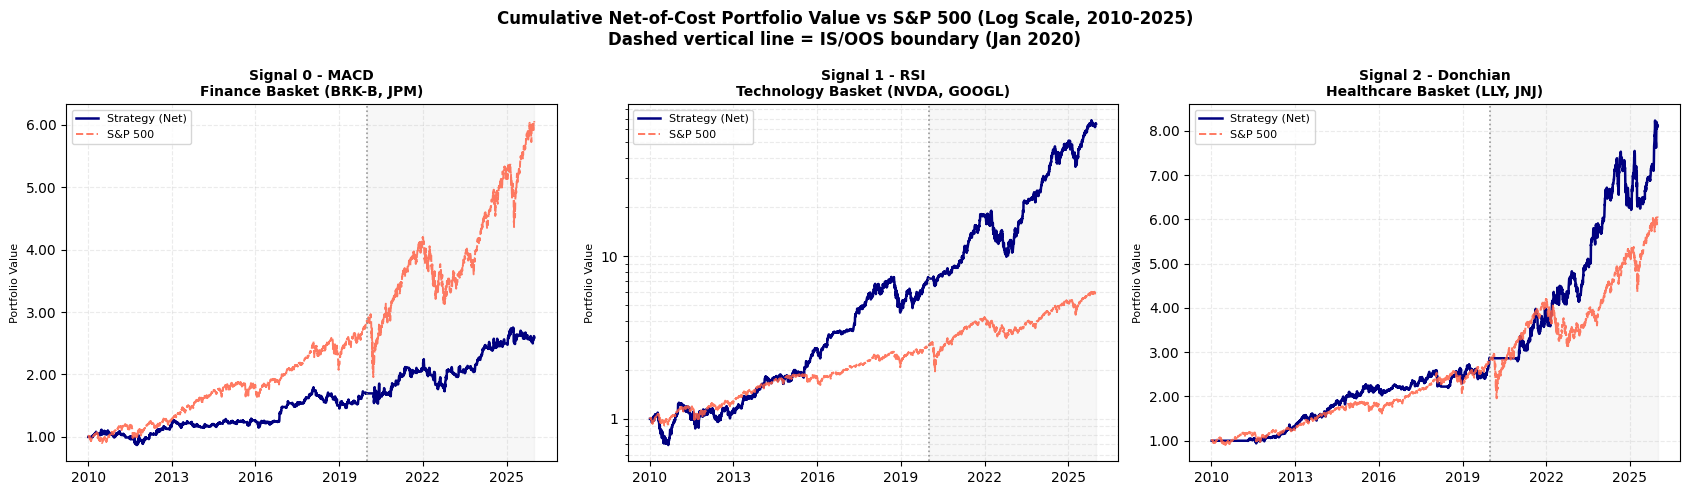

In [19]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    'Cumulative Net-of-Cost Portfolio Value vs S&P 500 (Log Scale, 2010-2025)\n'
    'Dashed vertical line = IS/OOS boundary (Jan 2020)',
    fontsize=12, fontweight='bold')

panels = [
    (axes[0], df_finance_is,    df_finance_oos,
     n_macd_is, n_macd_oos,
     'Signal 0 - MACD\nFinance Basket (BRK-B, JPM)'),
    (axes[1], df_tech_is,       df_tech_oos,
     n_rsi_is,  n_rsi_oos,
     'Signal 1 - RSI\nTechnology Basket (NVDA, GOOGL)'),
    (axes[2], df_healthcare_is, df_healthcare_oos,
     n_donchian_is,   n_donchian_oos,
     'Signal 2 - Donchian\nHealthcare Basket (LLY, JNJ)'),
]

for ax, df_is_, df_oos_, n_is_, n_oos_, title in panels:
    dates_is  = pd.to_datetime(df_is_.index).to_numpy()
    dates_oos = pd.to_datetime(df_oos_.index).to_numpy()
    dates_all = np.concatenate([dates_is, dates_oos])

    n_all   = np.concatenate([n_is_,
                               n_oos_ / n_oos_[0] * n_is_[-1]])
    spx_all = np.concatenate([_spx_slice(df_is_),
                               _spx_slice(df_oos_) / _spx_slice(df_oos_)[0]
                               * _spx_slice(df_is_)[-1]])

    ax.plot(dates_all, n_all,   color='navy',   lw=1.8, label='Strategy (Net)')
    ax.plot(dates_all, spx_all, color='tomato', lw=1.4,
            linestyle='--', label='S&P 500', alpha=0.85)

    # Use log scale only when values span multiple orders of magnitude
    if n_all.max() / n_all.min() > 10:
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))

    split_date = pd.Timestamp(OOS_START)
    ax.axvline(split_date, color='grey', lw=1.2, linestyle=':', alpha=0.8)
    ax.axvspan(split_date, dates_oos[-1], alpha=0.06, color='grey')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Portfolio Value', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

### 5.5 Drawdown Profiles

The drawdown series captures peak-to-trough declines over time:

$$DD_t = \frac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}$$

Key stress periods are shaded:
- **Red:** COVID-19 crash (Feb 19 - Mar 23, 2020)
- **Orange:** Fed rate-hike cycle (Jan - Dec 2022)

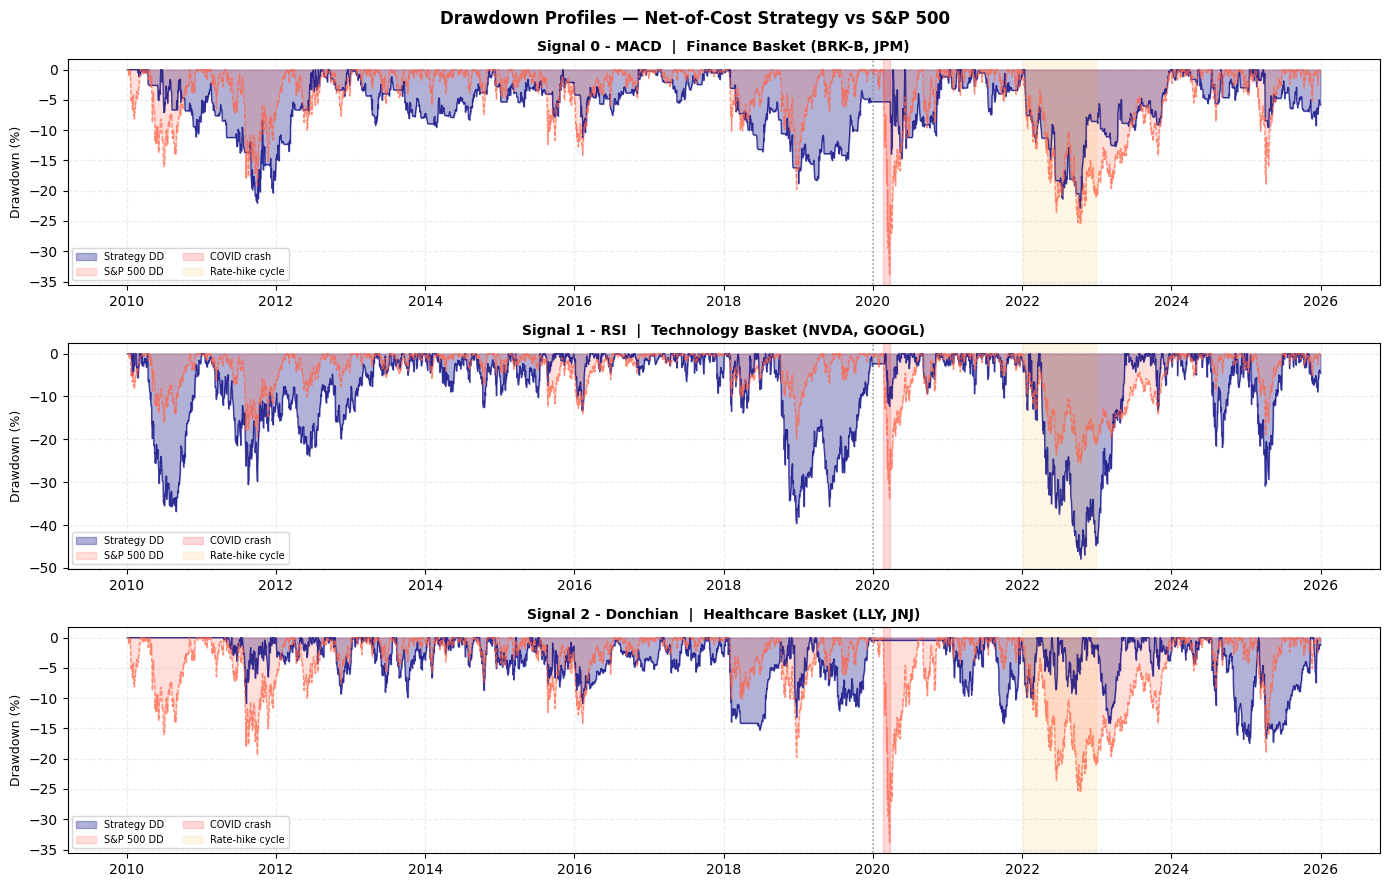

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
fig.suptitle('Drawdown Profiles — Net-of-Cost Strategy vs S&P 500',
             fontsize=12, fontweight='bold')

panels_dd = [
    (axes[0], df_finance_is,    df_finance_oos,
     n_macd_is, n_macd_oos,
     'Signal 0 - MACD  |  Finance Basket (BRK-B, JPM)'),
    (axes[1], df_tech_is,       df_tech_oos,
     n_rsi_is,  n_rsi_oos,
     'Signal 1 - RSI  |  Technology Basket (NVDA, GOOGL)'),
    (axes[2], df_healthcare_is, df_healthcare_oos,
     n_donchian_is,   n_donchian_oos,
     'Signal 2 - Donchian  |  Healthcare Basket (LLY, JNJ)'),
]

covid_start = pd.Timestamp('2020-02-19')
covid_end   = pd.Timestamp('2020-03-23')
hike_start  = pd.Timestamp('2022-01-03')
hike_end    = pd.Timestamp('2022-12-30')

for ax, df_is_, df_oos_, n_is_, n_oos_, title in panels_dd:
    dates_is  = pd.to_datetime(df_is_.index).to_numpy()
    dates_oos = pd.to_datetime(df_oos_.index).to_numpy()
    dates_all = np.concatenate([dates_is, dates_oos])

    n_all   = np.concatenate([n_is_,
                               n_oos_ / n_oos_[0] * n_is_[-1]])
    spx_all = np.concatenate([_spx_slice(df_is_),
                               _spx_slice(df_oos_) / _spx_slice(df_oos_)[0]
                               * _spx_slice(df_is_)[-1]])

    dd_strat = module.compute_drawdown_series(n_all)   * 100
    dd_spx   = module.compute_drawdown_series(spx_all) * 100

    ax.fill_between(dates_all, dd_strat, 0,
                    color='navy',   alpha=0.30, label='Strategy DD')
    ax.fill_between(dates_all, dd_spx,   0,
                    color='tomato', alpha=0.20, label='S&P 500 DD')
    ax.plot(dates_all, dd_strat, color='navy',   lw=0.9, alpha=0.7)
    ax.plot(dates_all, dd_spx,   color='tomato', lw=0.9,
            alpha=0.7, linestyle='--')

    ax.axvspan(covid_start, covid_end,
               alpha=0.15, color='red',    label='COVID crash')
    ax.axvspan(hike_start,  hike_end,
               alpha=0.10, color='orange', label='Rate-hike cycle')
    ax.axvline(pd.Timestamp(OOS_START),
               color='grey', lw=1.1, linestyle=':', alpha=0.8)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Drawdown (%)', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.legend(fontsize=7, loc='lower left', ncol=2)
    ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

### 5.6 Rolling 252-Day Sharpe Ratio

A time-varying risk-adjusted return profile reveals whether signal alpha
is stable or concentrated in specific market regimes. Persistent positive
rolling Sharpe values across both IS and OOS windows indicate a structural
edge. A collapse post-2020 would be a diagnostic flag for regime dependence.

References:
- McLean, R. D., & Pontiff, J. (2016). Does Publishing Research Destroy
  Stock Return Predictability? JF, 71(1), 5-32.

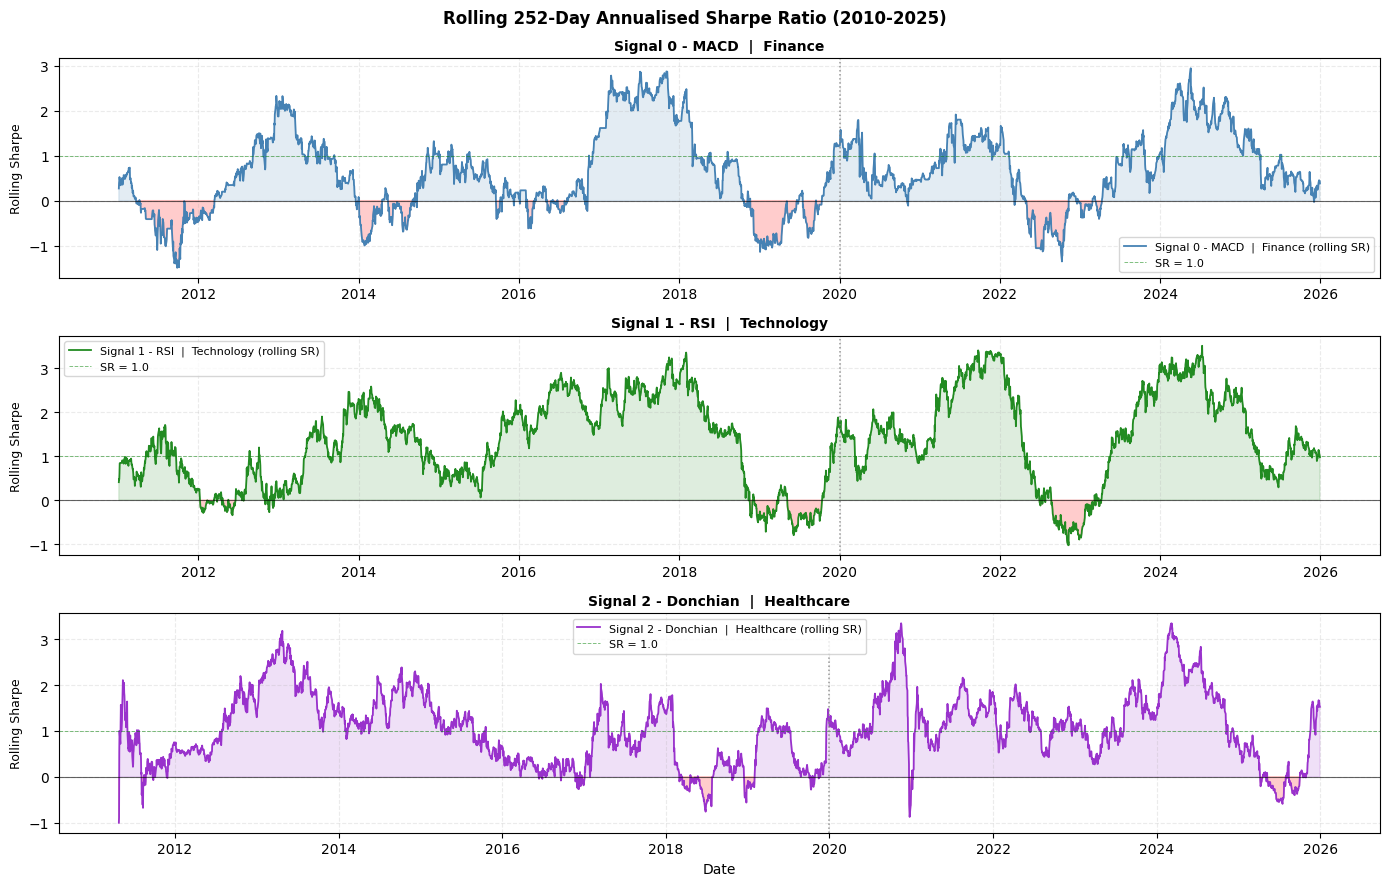

In [21]:
ROLL = 252

def rolling_sharpe_series(pv):
    # 252-day rolling annualised Sharpe ratio (pure NumPy)
    n  = len(pv)
    dr = np.concatenate(([0.0], pv[1:] / pv[:-1] - 1))
    rs = np.full(n, np.nan)
    for i in range(ROLL, n):
        w  = dr[i - ROLL:i]
        mu = np.sum(w) / ROLL
        sg = np.sqrt(np.sum((w - mu) ** 2) / ROLL)
        if sg > 1e-10:
            rs[i] = mu / sg * np.sqrt(ROLL)
    return rs

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
fig.suptitle('Rolling 252-Day Annualised Sharpe Ratio (2010-2025)',
             fontsize=12, fontweight='bold')

for ax, df_is_, df_oos_, n_is_, n_oos_, label, color in [
    (axes[0], df_finance_is,    df_finance_oos,
     n_macd_is, n_macd_oos,
     'Signal 0 - MACD  |  Finance',     'steelblue'),
    (axes[1], df_tech_is,       df_tech_oos,
     n_rsi_is,  n_rsi_oos,
     'Signal 1 - RSI  |  Technology',   'forestgreen'),
    (axes[2], df_healthcare_is, df_healthcare_oos,
     n_donchian_is,   n_donchian_oos,
     'Signal 2 - Donchian  |  Healthcare', 'darkorchid'),
]:
    dates_is  = pd.to_datetime(df_is_.index).to_numpy()
    dates_oos = pd.to_datetime(df_oos_.index).to_numpy()
    dates_all = np.concatenate([dates_is, dates_oos])
    n_all     = np.concatenate([n_is_,
                                 n_oos_ / n_oos_[0] * n_is_[-1]])
    rs        = rolling_sharpe_series(n_all)

    ax.plot(dates_all, rs, color=color, lw=1.3,
            label=f'{label} (rolling SR)')
    ax.axhline(0, color='black', lw=0.8, alpha=0.6)
    ax.axhline(1, color='green', lw=0.7, linestyle='--',
               alpha=0.5, label='SR = 1.0')
    ax.fill_between(dates_all, rs, 0,
                    where=~np.isnan(rs) & (rs > 0),
                    alpha=0.15, color=color)
    ax.fill_between(dates_all, rs, 0,
                    where=~np.isnan(rs) & (rs < 0),
                    alpha=0.20, color='red')
    ax.axvline(pd.Timestamp(OOS_START),
               color='grey', lw=1.1, linestyle=':', alpha=0.8)
    ax.set_ylabel('Rolling Sharpe', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.grid(True, alpha=0.25, linestyle='--')

axes[2].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.show()

## 6. IS to OOS Performance Decay Analysis

The table below measures the change in key metrics from IS to OOS.
A drop in Sortino of up to 40% is broadly consistent with post-publication
anomaly compression (McLean & Pontiff, 2016). A decay exceeding 70%
warrants a signal-level review. Positive decay — OOS outperforming IS —
can reflect favourable regime coincidence.

$$Decay\% = \frac{OOS - IS}{|IS|} \times 100$$

**References:**
- McLean, R. D., & Pontiff, J. (2016). Does Publishing Research Destroy
  Stock Return Predictability? JF, 71(1), 5-32.

In [22]:
# ── IS TO OOS DECAY TABLE ─────────────────────────────────────────────────────

def sortino_from_pv(pv):
    dr = np.concatenate(([0.0], pv[1:] / pv[:-1] - 1))
    return module.compute_sortino(dr[1:])

def sharpe_from_pv(pv):
    dr = np.concatenate(([0.0], pv[1:] / pv[:-1] - 1))
    return module.compute_sharpe(dr[1:])

signals_summary = [
    ('Signal 0 - MACD  |  Finance',    n_macd_is, n_macd_oos),
    ('Signal 1 - RSI   |  Technology', n_rsi_is,  n_rsi_oos),
    ('Signal 2 - Donchian | Healthcare', n_donchian_is,  n_donchian_oos),
]

metrics_fns = [
    ('Sortino',      sortino_from_pv,              '.3f'),
    ('Sharpe',       sharpe_from_pv,               '.3f'),
    ('CAGR',         module.compute_cagr,           '.2%'),
    ('Max Drawdown', module.compute_max_drawdown,   '.2%'),
]

for metric_name, fn, fmt in metrics_fns:
    print(f'\n{"="*68}')
    print(f'  Metric: {metric_name}')
    print(f'{"="*68}')
    print(f'  {"Signal":<30} {"IS":>8} {"OOS":>8} {"Delta":>8}  {"Decay%":>9}')
    print(f'  {"-"*62}')
    for label, n_is_, n_oos_ in signals_summary:
        v_is  = fn(n_is_)
        v_oos = fn(n_oos_)
        delta = v_oos - v_is
        decay = (delta / abs(v_is) * 100) if abs(v_is) > 1e-8 else np.nan
        decay_str = f'{decay:>8.1f}%' if not np.isnan(decay) else '     N/A'
        print(f'  {label:<30} {format(v_is, fmt):>8} '
              f'{format(v_oos, fmt):>8} {format(delta, fmt):>8}  {decay_str}')
    print(f'{"="*68}')


  Metric: Sortino
  Signal                               IS      OOS    Delta     Decay%
  --------------------------------------------------------------
  Signal 0 - MACD  |  Finance       0.753    0.840    0.087      11.6%
  Signal 1 - RSI   |  Technology    1.338    1.996    0.658      49.2%
  Signal 2 - Donchian | Healthcare    1.236    1.817    0.581      47.0%

  Metric: Sharpe
  Signal                               IS      OOS    Delta     Decay%
  --------------------------------------------------------------
  Signal 0 - MACD  |  Finance       0.507    0.566    0.059      11.6%
  Signal 1 - RSI   |  Technology    0.914    1.305    0.391      42.8%
  Signal 2 - Donchian | Healthcare    0.874    1.175    0.301      34.5%

  Metric: CAGR
  Signal                               IS      OOS    Delta     Decay%
  --------------------------------------------------------------
  Signal 0 - MACD  |  Finance       5.44%    7.34%    1.90%      34.9%
  Signal 1 - RSI   |  Technology   22.

### 6.1 Interpretation

The decay table compares in-sample and out-of-sample performance after freezing the selected parameters. Donchian should be judged by whether the breakout window chosen on 2010-2019 continues to produce acceptable 2020-2025 risk-adjusted returns, not by any later re-optimisation.


## 7. Period Comparison: 2000-2025 vs 2010-2025

### 7.1 Motivation

Our primary analysis uses data from 2010-2025, deliberately excluding the
2008 financial crisis to avoid calibrating parameters on a structural break.
However this raises a legitimate question: are our signals and parameters
robust to a longer data history that includes the dot-com crash (2000-2002)
and the 2008 financial crisis?

This section tests whether:
- The IS-optimal parameters from 2010-2019 remain reasonable when evaluated
  on the extended 2000-2025 period
- Signal performance degrades significantly when exposed to pre-2010 market
  regimes
- The 2010 start date is a justified choice or an arbitrary one that
  flatters our results

### 7.2 Approach

We download the extended dataset (2000-2025) for all six stocks and apply
the same IS-optimal parameters found in Section 4. We do NOT re-optimize
on the extended period — the parameters remain frozen. This tests whether
the signals generalize to regimes they were never calibrated on.

**Note:** Not all stocks have data going back to 2000. NVDA and GOOGL were
listed later (NVDA in 1999, GOOGL in 2004). We use available data only.

In [23]:
# EXTENDED DATA LOADING (2000-2025)
# Download or load from cache - reuses existing _load_basket function.

df_finance_ext = _load_basket(FINANCE_TICKERS,
                              'finance_ext.csv',
                              start='2000-01-01',
                              end='2025-12-31')

df_tech_ext = _load_basket(TECH_TICKERS,
                           'tech_ext.csv',
                           start='2000-01-01',
                           end='2025-12-31')

df_healthcare_ext = _load_basket(HEALTHCARE_TICKERS,
                                 'healthcare_ext.csv',
                                 start='2000-01-01',
                                 end='2025-12-31')

spx_ext_csv = data_dir / 'spx_ext.csv'
if spx_ext_csv.exists():
    df_spx_ext = pd.read_csv(spx_ext_csv, index_col=0, parse_dates=True)
    print('Loaded spx_ext.csv from cache.')
else:
    df_spx_ext, _ = module.download_stock_price_data(['^GSPC'], '2000-01-01', '2025-12-31')
    df_spx_ext.to_csv(spx_ext_csv)
df_spx_ext.index = pd.to_datetime(df_spx_ext.index)

print('Extended period data loaded:')
print(f'  Finance:    {df_finance_ext.index[0].date()} to '
      f'{df_finance_ext.index[-1].date()} ({len(df_finance_ext)} days)')
print(f'  Technology: {df_tech_ext.index[0].date()} to '
      f'{df_tech_ext.index[-1].date()} ({len(df_tech_ext)} days)')
print(f'  Healthcare: {df_healthcare_ext.index[0].date()} to '
      f'{df_healthcare_ext.index[-1].date()} ({len(df_healthcare_ext)} days)')


Loaded finance_ext.csv from cache.
Loaded tech_ext.csv from cache.
Loaded healthcare_ext.csv from cache.


Extended period data loaded:
  Finance:    2000-01-03 to 2025-12-30 (6538 days)
  Technology: 2004-08-19 to 2025-12-30 (5376 days)
  Healthcare: 2000-01-03 to 2025-12-30 (6538 days)


In [24]:
# ── RUN PORTFOLIOS ON EXTENDED PERIOD ────────────────────────────────────────
# Apply frozen IS-optimal parameters to full 2000-2025 data
# No re-optimization — parameters remain exactly as found in Section 4

def _spx_slice_ext(df_basket):
    # Extract SPX values aligned to extended basket date index
    aligned = df_spx_ext.reindex(df_basket.index, method='ffill')
    col = '^GSPC' if '^GSPC' in aligned.columns else aligned.columns[0]
    v   = aligned[col].to_numpy(dtype=float)
    return v / v[0]

# Extended period portfolios
_, n_macd_ext = basket_portfolio_value(
    module.macd_signal,    df_finance_ext,    _best_macd_params)
_, n_rsi_ext  = basket_portfolio_value(
    module.rsi_signal,     df_tech_ext,       _best_rsi_params)
_, n_donchian_ext   = basket_portfolio_value(
    module.donchian_signal,  df_healthcare_ext, _best_donchian_params)

# Original 2010-2025 portfolios for comparison
_, n_macd_full = basket_portfolio_value(
    module.macd_signal,    df_finance,    _best_macd_params)
_, n_rsi_full  = basket_portfolio_value(
    module.rsi_signal,     df_tech,       _best_rsi_params)
_, n_donchian_full   = basket_portfolio_value(
    module.donchian_signal,  df_healthcare, _best_donchian_params)

print('Extended period portfolios computed successfully.')

Extended period portfolios computed successfully.


In [25]:
# ── PERIOD COMPARISON TABLE ───────────────────────────────────────────────────
# Compare key metrics across the two data periods

def period_metrics(pv, label):
    # Compute key metrics from a portfolio value series
    dr      = np.concatenate(([0.0], pv[1:] / pv[:-1] - 1))
    sortino = module.compute_sortino(dr[1:])
    sharpe  = module.compute_sharpe(dr[1:])
    cagr    = module.compute_cagr(pv)
    mdd     = module.compute_max_drawdown(pv)
    return {'label': label, 'Sortino': sortino, 'Sharpe': sharpe,
            'CAGR': cagr, 'Max DD': mdd}

comparisons = [
    ('MACD  |  Finance',
     period_metrics(n_macd_full, '2010-2025'),
     period_metrics(n_macd_ext,  '2000-2025')),
    ('RSI   |  Technology',
     period_metrics(n_rsi_full,  '2010-2025'),
     period_metrics(n_rsi_ext,   '2000-2025')),
    ('Donchian | Healthcare',
     period_metrics(n_donchian_full,   '2010-2025'),
     period_metrics(n_donchian_ext,    '2000-2025')),
]

print('Period Comparison: 2010-2025 vs 2000-2025')
print('(Same IS-optimal parameters applied to both periods)')
print()

for signal_label, m1, m2 in comparisons:
    print(f'{"="*60}')
    print(f'  {signal_label}')
    print(f'{"="*60}')
    print(f'  {"Metric":<18} {"2010-2025":>12} {"2000-2025":>12}  {"Change":>10}')
    print(f'  {"-"*54}')
    for metric in ['Sortino', 'Sharpe', 'CAGR', 'Max DD']:
        v1  = m1[metric]
        v2  = m2[metric]
        fmt = '.2%' if metric in ['CAGR', 'Max DD'] else '.3f'
        chg = v2 - v1
        chg_str = f'{chg:+.3f}' if fmt == '.3f' else f'{chg:+.2%}'
        print(f'  {metric:<18} {format(v1, fmt):>12} '
              f'{format(v2, fmt):>12}  {chg_str:>10}')
    print()

Period Comparison: 2010-2025 vs 2000-2025
(Same IS-optimal parameters applied to both periods)

  MACD  |  Finance
  Metric                2010-2025    2000-2025      Change
  ------------------------------------------------------
  Sortino                   0.762        0.526      -0.236
  Sharpe                    0.514        0.348      -0.166
  CAGR                      5.94%        4.38%      -1.56%
  Max DD                  -22.88%      -47.74%     -24.86%

  RSI   |  Technology
  Metric                2010-2025    2000-2025      Change
  ------------------------------------------------------
  Sortino                   1.679        1.486      -0.193
  Sharpe                    1.127        1.003      -0.123
  CAGR                     33.49%       30.47%      -3.01%
  Max DD                  -47.92%      -72.24%     -24.33%

  Donchian | Healthcare
  Metric                2010-2025    2000-2025      Change
  ------------------------------------------------------
  Sortino        

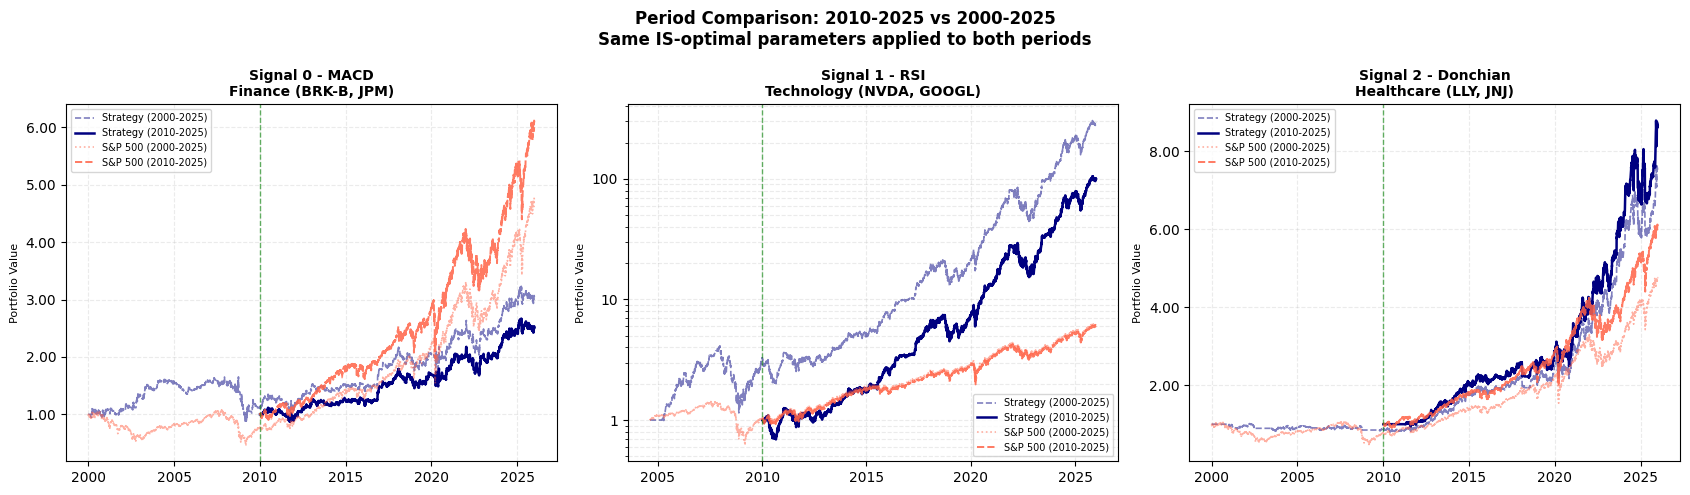

In [26]:
# ── EQUITY CURVE COMPARISON ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    'Period Comparison: 2010-2025 vs 2000-2025\n'
    'Same IS-optimal parameters applied to both periods',
    fontsize=12, fontweight='bold')

panels_pc = [
    (axes[0], df_finance,    df_finance_ext,
     n_macd_full, n_macd_ext,
     'Signal 0 - MACD\nFinance (BRK-B, JPM)'),
    (axes[1], df_tech,       df_tech_ext,
     n_rsi_full,  n_rsi_ext,
     'Signal 1 - RSI\nTechnology (NVDA, GOOGL)'),
    (axes[2], df_healthcare, df_healthcare_ext,
     n_donchian_full,   n_donchian_ext,
     'Signal 2 - Donchian\nHealthcare (LLY, JNJ)'),
]

for ax, df_main, df_ext, n_main, n_ext, title in panels_pc:
    dates_main = pd.to_datetime(df_main.index).to_numpy()
    dates_ext  = pd.to_datetime(df_ext.index).to_numpy()

    spx_main = _spx_slice(df_main)
    spx_ext  = _spx_slice_ext(df_ext)

    # Plot extended period (2000-2025) in lighter color
    ax.plot(dates_ext,  n_ext,  color='navy',   lw=1.2,
            alpha=0.5, label='Strategy (2000-2025)', linestyle='--')
    ax.plot(dates_main, n_main, color='navy',   lw=1.8,
            label='Strategy (2010-2025)')
    ax.plot(dates_ext,  spx_ext, color='tomato', lw=1.2,
            alpha=0.5, linestyle=':',  label='S&P 500 (2000-2025)')
    ax.plot(dates_main, spx_main, color='tomato', lw=1.4,
            linestyle='--', label='S&P 500 (2010-2025)', alpha=0.85)

    # Mark 2010 start
    ax.axvline(pd.Timestamp('2010-01-01'),
               color='green', lw=1.0, linestyle='--', alpha=0.6)

    # Use log or linear scale depending on value range
    if n_ext.max() / n_ext.min() > 10:
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:g}'))
    else:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Portfolio Value', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.legend(fontsize=7)
    ax.grid(True, which='both', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

### 7.3 Interpretation

The period comparison applies the same frozen parameters to the longer 2000-2025 sample. This is a robustness check: if Donchian on Healthcare changes materially over the extended period, that suggests the 2010 start date and the post-crisis regime matter for the breakout result.


## 8. Conclusion and Final Parameter Justification

This notebook now tests MACD, RSI, and Donchian Channel Breakout under a consistent protocol:

- Parameters are selected only on the 2010-2019 in-sample period.
- Out-of-sample performance from 2020-2025 is used only for validation.
- Strategy returns use yesterday's signal to earn today's return.
- Results include 10 bps one-way transaction costs in the basket backtest.

Donchian replaces the old third-signal experiment and is applied to the Healthcare basket. Its selected window and OOS metrics should be read from the executed optimisation and performance tables above.


In [27]:
# Donchian signal behaviour check on Healthcare basket
for stock in HEALTHCARE_TICKERS:
    sig = module.donchian_signal(df_healthcare_is[stock], **_best_donchian_params)
    active_days = int(sig['signal'].sum())
    trades = int((sig['position_change'] > 0).sum())
    active_pct = active_days / len(sig) * 100
    print(f'{stock} Donchian signal analysis (IS):')
    print(f'  Best params : {_best_donchian_params}')
    print(f'  Active days : {active_days} ({active_pct:.1f}%)')
    print(f'  Entries     : {trades}')


LLY Donchian signal analysis (IS):
  Best params : {'window': 200}
  Active days : 1859 (73.9%)
  Entries     : 3
JNJ Donchian signal analysis (IS):
  Best params : {'window': 200}
  Active days : 1968 (78.2%)
  Entries     : 3
